# 04 - The control band

Derives a time-varying optimal arousal trajectory from the hard-course control
trials, measures how far each trial deviates from it, and asks whether the two
sensitivity groups need different band widths.

"Control trials" here means conditions 1 and 2, silence and the half-sham
condition. Condition 2 still delivers 50% veridical feedback; see
`METHODS.md`.

In [1]:
import sys
sys.path.insert(0, "..")   # or: pip install -e .. to import `arousal` directly

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from scipy.stats import linregress, pearsonr, sem, ttest_ind

from arousal import config as cfg
from arousal import control as C
from arousal.plotting import (BLUE, CRIMSON, DKBLUE, DKRED, FS_AN, FS_AX,
                              FS_PAN, FS_TK, GRAY, GREEN, RED, holm, panel, tidy)

SENSITIVE_MULT = 1.5
TOLERANT_MULT = 2.5
MAX_TIME = 60         # seconds shown in the trajectory panels

df = pd.read_pickle(cfg.DATA / "trial_table.pkl")
trials = df[(df["difficulty"] == 1)
            & (df["condition"].isin(cfg.CONTROL_CONDITIONS))].reset_index(drop=True)
print(f"hard-course control trials: {len(trials)} "
      f"from {trials['subject'].nunique()} subjects")

hard-course control trials: 113 from 16 subjects


## The optimal trajectory

Mean flight time is binned by decoded arousal (5 units) and trial time (1 s).
At each time bin the optimum is the performance-weighted mean arousal, and the
band half-width is the weighted SD around it; both series are then smoothed with
a cubic fit weighted by how many observations each bin contributed.

In [2]:
surface = C.performance_surface(trials)
traj = C.optimal_trajectory(surface)

fitted = traj["confidence"] >= C.MIN_CONFIDENCE_FOR_FIT
print(f"time bins with enough data to fit: {fitted.sum()} of {len(fitted)} "
      f"(up to {traj['time_centers'][fitted].max():.0f} s)")
print(f"optimum over the fitted range: "
      f"{traj['optimal'][fitted].min():.1f} to {traj['optimal'][fitted].max():.1f}")

time bins with enough data to fit: 39 of 74 (up to 38 s)
optimum over the fitted range: 3.0 to 35.2


## Table 1: deviation metrics vs performance

All four metrics are derived from the same per-bin above/below classification.
`pct_in_band` is exactly `100 - pct_above`, and `excursion_rate` counts
above-band bins per minute, so all three are monotone functions of one another;
they are reported separately to match the original table.

In [3]:
metrics = C.deviation_metrics(trials, traj, band_mult=1.0)
assert len(metrics) == len(trials)

table = [("% time above band", "pct_above"),
         ("% time in band", "pct_in_band"),
         ("Mean excursion magnitude", "mean_excursion"),
         ("Excursion rate (per min)", "excursion_rate")]
raw = [pearsonr(metrics[col], metrics["performance"]) for _, col in table]
adjusted = holm([r.pvalue for r in raw])

print(f"{'Metric':<28}{'Pearson r':>11}{'p (Holm)':>11}")
for (label, _), r, p in zip(table, raw, adjusted):
    print(f"{label:<28}{r.statistic:>+11.3f}{p:>11.3f}")

Metric                        Pearson r   p (Holm)
% time above band                -0.308      0.004
% time in band                   +0.308      0.004
Mean excursion magnitude         -0.254      0.007
Excursion rate (per min)         -0.308      0.004


## Figure 4

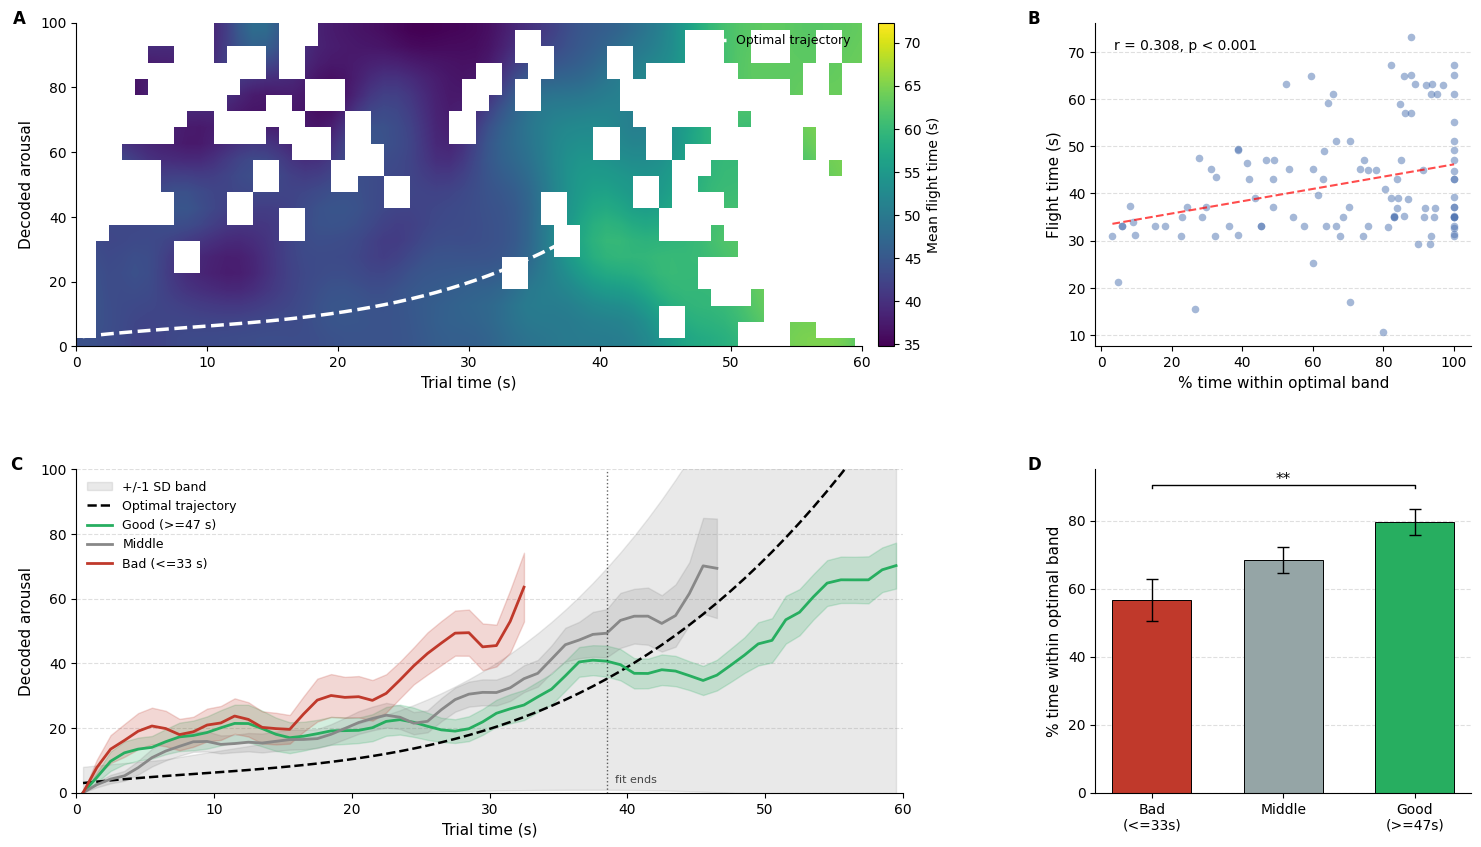

bad 56.6%  middle 68.4%  good 79.6%
Holm-corrected p: [0.1265 0.0071 0.1265]


In [4]:
fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32,
                       width_ratios=[2.2, 1])
ax_a, ax_b = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])
ax_c, ax_d = fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])

# --- A: performance surface ---------------------------------------------------
extent = [surface["time_bins"][0], surface["time_bins"][-1],
          surface["arousal_bins"][0], surface["arousal_bins"][-1]]
im = ax_a.imshow(surface["perf_smooth"], aspect="auto", origin="lower",
                 extent=extent, cmap="viridis", interpolation="bilinear")
cbar = fig.colorbar(im, ax=ax_a, pad=0.02, fraction=0.030)
cbar.set_label("Mean flight time (s)", fontsize=FS_TK)
cbar.ax.tick_params(labelsize=FS_TK)

ax_a.plot(traj["time_centers"][fitted], traj["optimal"][fitted], color="white",
          ls="--", lw=2.5, label="Optimal trajectory")
ax_a.set_xlabel("Trial time (s)", fontsize=FS_AX)
ax_a.set_ylabel("Decoded arousal", fontsize=FS_AX)
ax_a.set_xlim(0, MAX_TIME)
ax_a.set_ylim(surface["arousal_bins"][0], surface["arousal_bins"][-1])
ax_a.legend(fontsize=9, frameon=False, loc="upper right")
tidy(ax_a, grid_axis="none")
panel(ax_a, "A", x=-0.08)

# --- B: % time in band vs flight time -----------------------------------------
r, p = pearsonr(metrics["pct_in_band"], metrics["performance"])
ax_b.scatter(metrics["pct_in_band"], metrics["performance"], alpha=0.5, s=30,
             color=BLUE, linewidths=0, zorder=2)
fit = np.polyfit(metrics["pct_in_band"], metrics["performance"], 1)
xs = np.linspace(metrics["pct_in_band"].min(), metrics["pct_in_band"].max(), 200)
ax_b.plot(xs, np.poly1d(fit)(xs), "r--", alpha=0.7, lw=1.5)
ax_b.text(0.05, 0.95, f"r = {r:.3f}, " +
          ("p < 0.001" if p < 0.001 else f"p = {p:.3f}"),
          transform=ax_b.transAxes, fontsize=FS_TK, va="top")
ax_b.set_xlabel("% time within optimal band", fontsize=FS_AX)
ax_b.set_ylabel("Flight time (s)", fontsize=FS_AX)
tidy(ax_b)
panel(ax_b, "B", x=-0.18)

# --- C: mean trajectories by performance tertile ------------------------------
q25, q75 = np.percentile(trials["performance"] / cfg.FS, [25, 75])
perf_sec = trials["performance"] / cfg.FS
groups = {
    "top": trials.index[perf_sec >= q75],
    "mid": trials.index[(perf_sec > q25) & (perf_sec < q75)],
    "bottom": trials.index[perf_sec <= q25],
}


def mean_trace(idx):
    rows = []
    for i in idx:
        binned = C._binned_arousal(trials.loc[i, "new_arousal"])[:MAX_TIME]
        if len(binned) < 5:
            continue
        rows.append(np.pad(binned, (0, MAX_TIME - len(binned)),
                           constant_values=np.nan))
    arr = np.array(rows)
    # Later bins are only populated by the longer trials; leave bins with fewer
    # than two contributing trials empty rather than averaging a single trace.
    n = np.sum(~np.isnan(arr), axis=0)
    mean = np.full(MAX_TIME, np.nan)
    se = np.full(MAX_TIME, np.nan)
    ok = n >= 2
    mean[ok] = np.nanmean(arr[:, ok], axis=0)
    se[ok] = np.nanstd(arr[:, ok], axis=0, ddof=1) / np.sqrt(n[ok])
    return mean, se


opt_c, std_c = traj["optimal"][:MAX_TIME], traj["std"][:MAX_TIME]
t_c = traj["time_centers"][:MAX_TIME]
ax_c.fill_between(t_c, opt_c - std_c, opt_c + std_c, alpha=0.18, color=GRAY,
                  label="+/-1 SD band")
ax_c.plot(t_c, opt_c, color="black", lw=1.8, ls="--", label="Optimal trajectory")
for key, color, label in [("top", GREEN, f"Good (>={q75:.0f} s)"),
                          ("mid", GRAY, "Middle"),
                          ("bottom", CRIMSON, f"Bad (<={q25:.0f} s)")]:
    mean, se = mean_trace(groups[key])
    ok = ~np.isnan(mean)
    ax_c.fill_between(t_c[ok], (mean - se)[ok], (mean + se)[ok], alpha=0.2,
                      color=color)
    ax_c.plot(t_c[ok], mean[ok], color=color, lw=2.0, label=label)

ax_c.set_xlabel("Trial time (s)", fontsize=FS_AX)
ax_c.set_ylabel("Decoded arousal", fontsize=FS_AX)
ax_c.set_xlim(0, MAX_TIME)
ax_c.set_ylim(surface["arousal_bins"][0], surface["arousal_bins"][-1])
tidy(ax_c)
# Beyond this point the cubic trajectory is extrapolated: too few trials survive
# that long to fit it.
fit_end = traj["time_centers"][fitted].max()
if fit_end < MAX_TIME:
    ax_c.axvline(fit_end, color="black", lw=1.0, ls=":", alpha=0.6)
    ax_c.text(fit_end + 0.6, 3, "fit ends", fontsize=8, alpha=0.7)
ax_c.legend(fontsize=9, frameon=False, loc="upper left")
panel(ax_c, "C", x=-0.08)

# --- D: % in band by performance group ----------------------------------------
bad = metrics.loc[metrics["performance"] <= q25, "pct_in_band"]
mid = metrics.loc[(metrics["performance"] > q25)
                  & (metrics["performance"] < q75), "pct_in_band"]
good = metrics.loc[metrics["performance"] >= q75, "pct_in_band"]
bars_data = [bad, mid, good]
pairs = [(0, 1), (0, 2), (1, 2)]
p_holm = holm([ttest_ind(bars_data[a], bars_data[b]).pvalue for a, b in pairs])

ax_d.bar(range(3), [g.mean() for g in bars_data],
         yerr=[sem(g) for g in bars_data], capsize=4,
         color=[CRIMSON, "#95a5a6", GREEN], edgecolor="black", linewidth=0.7,
         width=0.6, zorder=2, error_kw=dict(lw=1.0))
top = max(g.mean() for g in bars_data) + 6
for level, ((a, b), p) in enumerate(zip(pairs, p_holm)):
    if p < 0.05:
        y = top + level * 4
        ax_d.plot([a, a, b, b], [y, y + 1, y + 1, y], lw=1.0, color="black")
        ax_d.text((a + b) / 2, y + 1.2, "**" if p < 0.01 else "*", ha="center",
                  fontsize=11)
ax_d.set_xticks(range(3))
ax_d.set_xticklabels([f"Bad\n(<={q25:.0f}s)", "Middle", f"Good\n(>={q75:.0f}s)"],
                     fontsize=FS_TK)
ax_d.set_ylabel("% time within optimal band", fontsize=FS_AX)
tidy(ax_d)
panel(ax_d, "D", x=-0.18)

cfg.FIGURES.mkdir(exist_ok=True)
plt.savefig(cfg.FIGURES / "figure_4.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"bad {bad.mean():.1f}%  middle {mid.mean():.1f}%  good {good.mean():.1f}%")
print("Holm-corrected p:", np.round(p_holm, 4))

## Sensitivity groups

`sensitivity = -HRV_z + gamma_z`, split at the median. The median is taken over
*trials*, not subjects, which is how the split is defined; it happens
to give 8 subjects per group here.

In [5]:
metrics["hrv_z"] = trials["hrv_z"].to_numpy()
metrics["gamma_z"] = trials["gamma_z"].to_numpy()
metrics["score"] = C.sensitivity_score(metrics)

median_score = metrics["score"].median()
median_hrv = metrics["hrv_z"].median()
median_gamma = metrics["gamma_z"].median()

sensitive_idx = np.where(metrics["score"] > median_score)[0]
tolerant_idx = np.where(metrics["score"] <= median_score)[0]
for label, idx in [("sensitive", sensitive_idx), ("tolerant", tolerant_idx)]:
    print(f"  {label:<10} {len(idx):>3} trials, "
          f"{trials.iloc[idx]['subject'].nunique()} subjects")

  sensitive   54 trials, 8 subjects
  tolerant    59 trials, 8 subjects


## Figure 5: deviation-performance coupling by group

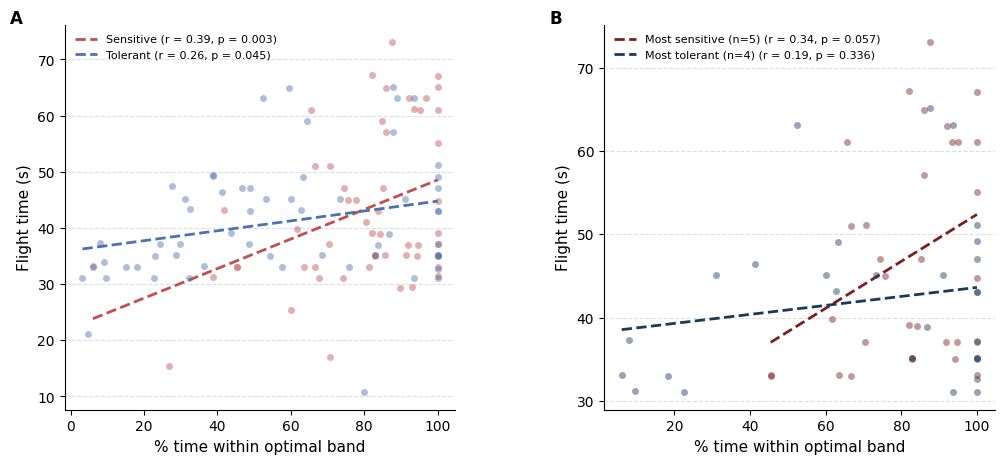

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plt.subplots_adjust(wspace=0.38)


def scatter_groups(ax, groups, letter):
    for frame, label, color in groups:
        x = frame["pct_in_band"].to_numpy()
        y = frame["performance"].to_numpy()
        if len(x) < 3:
            continue
        ax.scatter(x, y, alpha=0.45, s=25, color=color, linewidths=0, zorder=2)
        lr = linregress(x, y)
        xs = np.linspace(x.min(), x.max(), 200)
        ax.plot(xs, lr.slope * xs + lr.intercept, color=color, lw=2.0, ls="--",
                label=f"{label} (r = {lr.rvalue:.2f}, "
                      f"{'p < 0.001' if lr.pvalue < 0.001 else f'p = {lr.pvalue:.3f}'})")
    ax.set_xlabel("% time within optimal band", fontsize=FS_AX)
    ax.set_ylabel("Flight time (s)", fontsize=FS_AX)
    tidy(ax)
    ax.legend(fontsize=8, frameon=False, loc="upper left")
    panel(ax, letter)


scatter_groups(axes[0], [
    (metrics.iloc[sensitive_idx], "Sensitive", RED),
    (metrics.iloc[tolerant_idx], "Tolerant", BLUE)], "A")

extreme_sens = metrics[(metrics["hrv_z"] <= median_hrv)
                       & (metrics["gamma_z"] > median_gamma)]
extreme_tol = metrics[(metrics["hrv_z"] > median_hrv)
                      & (metrics["gamma_z"] <= median_gamma)]
n_s = trials.loc[extreme_sens.index, "subject"].nunique()
n_t = trials.loc[extreme_tol.index, "subject"].nunique()
scatter_groups(axes[1], [
    (extreme_sens, f"Most sensitive (n={n_s})", DKRED),
    (extreme_tol, f"Most tolerant (n={n_t})", DKBLUE)], "B")

plt.savefig(cfg.FIGURES / "figure_5.png", dpi=300, bbox_inches="tight")
plt.show()

## Figure 6: personalised band widths

The multiplier grid is searched separately within each group, maximising the
good-vs-bad Cohen's d on `% time above band`. Both the search and the evaluation
use the same trials.

In [7]:
sweeps = {
    "sensitive": C.band_width_sweep(trials, traj, sensitive_idx),
    "tolerant": C.band_width_sweep(trials, traj, tolerant_idx),
}
for label, (ds, ps) in sweeps.items():
    best = int(np.nanargmax(ds))
    at_one = C.BAND_MULTIPLIERS.index(1.0)
    print(f"  {label:<10} peak d = {ds[best]:.2f} at m = "
          f"{C.BAND_MULTIPLIERS[best]}, d at m = 1.0 is {ds[at_one]:.2f}")

  sensitive  peak d = 1.33 at m = 1.75, d at m = 1.0 is 1.29
  tolerant   peak d = 1.10 at m = 2.5, d at m = 1.0 is 0.86


In [8]:
universal = C.deviation_metrics(trials, traj, 1.0)
personalised = pd.concat([
    C.deviation_metrics(trials, traj, SENSITIVE_MULT, sensitive_idx),
    C.deviation_metrics(trials, traj, TOLERANT_MULT, tolerant_idx),
], ignore_index=True)

r_uni = linregress(universal["pct_in_band"], universal["performance"]).rvalue
r_per = linregress(personalised["pct_in_band"], personalised["performance"]).rvalue
print(f"deviation-performance r: universal {r_uni:.3f} -> personalised {r_per:.3f}")

deviation-performance r: universal 0.308 -> personalised 0.359


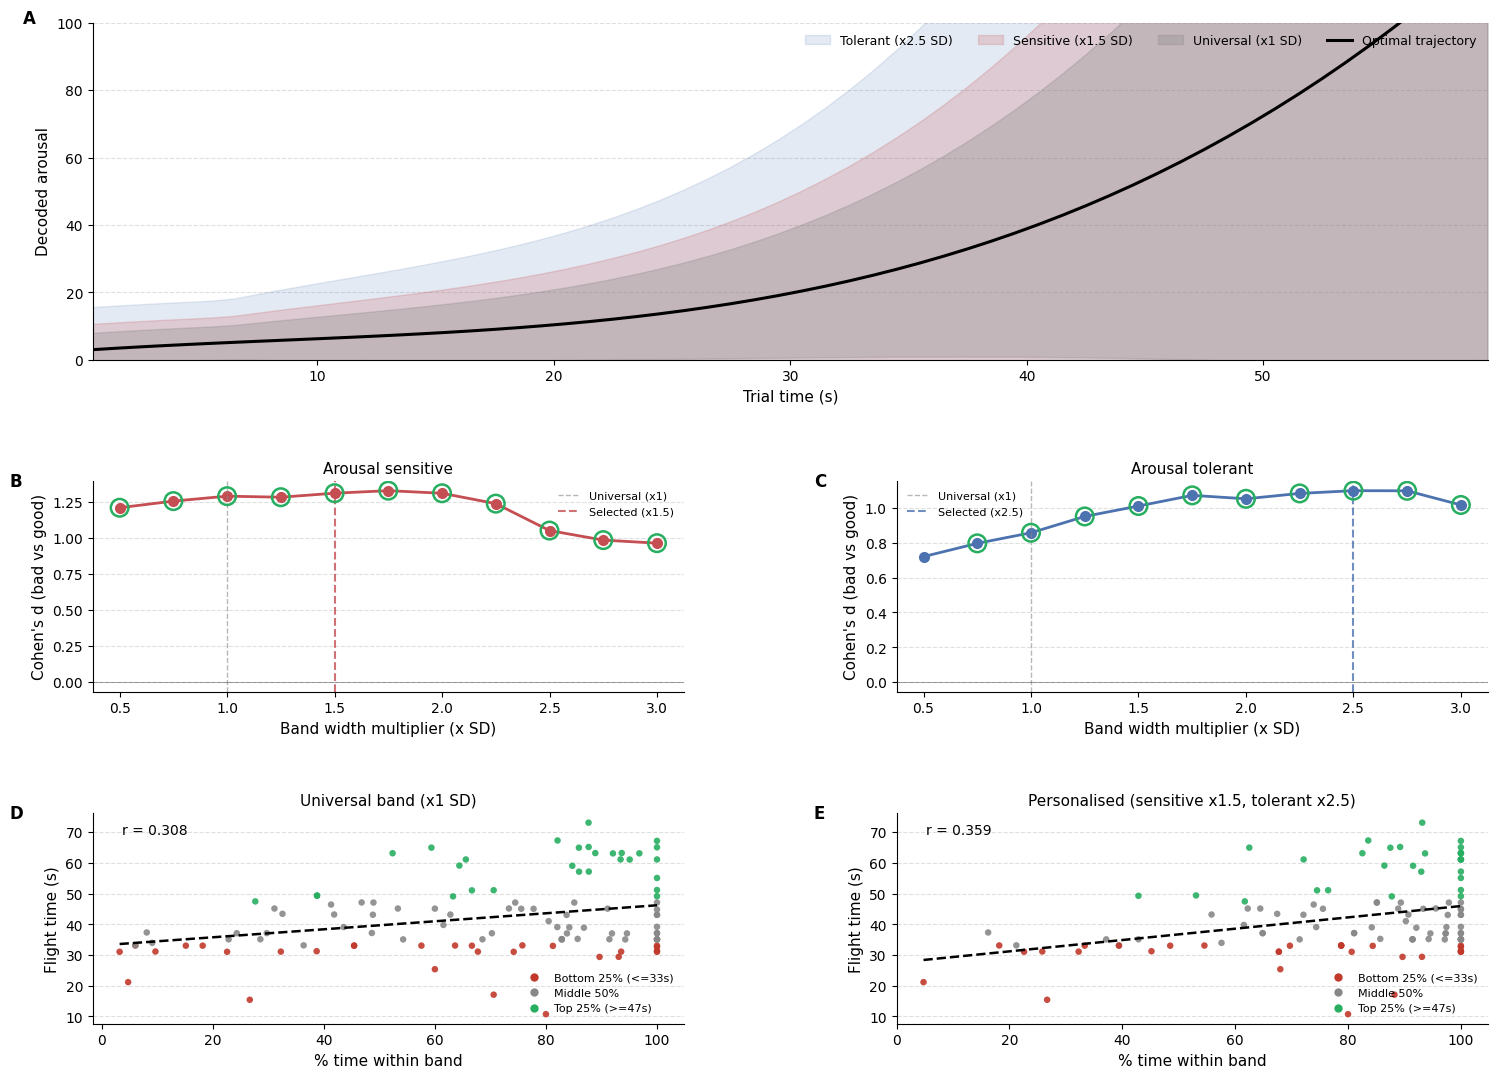

In [9]:
fig = plt.figure(figsize=(18, 13))
gs = gridspec.GridSpec(3, 2, figure=fig, height_ratios=[1.6, 1, 1],
                       hspace=0.48, wspace=0.36)
ax_a = fig.add_subplot(gs[0, :])
ax_b1, ax_b2 = fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])
ax_c1, ax_c2 = fig.add_subplot(gs[2, 0]), fig.add_subplot(gs[2, 1])

# --- A: the three bands -------------------------------------------------------
t = traj["time_centers"][:MAX_TIME]
opt, std = traj["optimal"][:MAX_TIME], traj["std"][:MAX_TIME]
ax_a.fill_between(t, opt - TOLERANT_MULT * std, opt + TOLERANT_MULT * std,
                  alpha=0.15, color=BLUE, label=f"Tolerant (x{TOLERANT_MULT} SD)")
ax_a.fill_between(t, opt - SENSITIVE_MULT * std, opt + SENSITIVE_MULT * std,
                  alpha=0.20, color=RED, label=f"Sensitive (x{SENSITIVE_MULT} SD)")
ax_a.fill_between(t, opt - std, opt + std, alpha=0.30, color=GRAY,
                  label="Universal (x1 SD)")
ax_a.plot(t, opt, color="black", lw=2.2, label="Optimal trajectory")
ax_a.set_xlabel("Trial time (s)", fontsize=FS_AX)
ax_a.set_ylabel("Decoded arousal", fontsize=FS_AX)
ax_a.set_xlim(t[0], t[-1])
ax_a.set_ylim(0, 100)
tidy(ax_a)
ax_a.legend(fontsize=9, frameon=False, loc="upper right", ncol=4)
panel(ax_a, "A", x=-0.05)

# --- B/C: effect size against band width --------------------------------------
for ax, key, color, title, chosen, letter in [
        (ax_b1, "sensitive", RED, "Arousal sensitive", SENSITIVE_MULT, "B"),
        (ax_b2, "tolerant", BLUE, "Arousal tolerant", TOLERANT_MULT, "C")]:
    ds, ps = sweeps[key]
    ax.plot(C.BAND_MULTIPLIERS, ds, "o-", color=color, lw=2.0, ms=7)
    for m, d, p in zip(C.BAND_MULTIPLIERS, ds, ps):
        if not np.isnan(p) and p < 0.05:
            ax.scatter([m], [d], s=160, facecolors="none", edgecolors=GREEN,
                       linewidths=1.8, zorder=4)
    ax.axvline(1.0, color=GRAY, lw=1.0, ls="--", alpha=0.6, label="Universal (x1)")
    ax.axvline(chosen, color=color, lw=1.5, ls="--", alpha=0.8,
               label=f"Selected (x{chosen})")
    ax.axhline(0, color="black", lw=0.6, alpha=0.4)
    ax.set_xlabel("Band width multiplier (x SD)", fontsize=FS_AX)
    ax.set_ylabel("Cohen's d (bad vs good)", fontsize=FS_AX)
    ax.set_title(title, fontsize=FS_AX, pad=6)
    tidy(ax)
    ax.legend(fontsize=8, frameon=False)
    panel(ax, letter)

# --- D/E: universal vs personalised -------------------------------------------
def scatter_band(ax, frame, letter, title):
    p25, p75 = np.percentile(frame["performance"], [25, 75])
    colors = np.where(frame["performance"] <= p25, CRIMSON,
                      np.where(frame["performance"] >= p75, GREEN, GRAY))
    x = frame["pct_in_band"].to_numpy()
    y = frame["performance"].to_numpy()
    ax.scatter(x, y, c=colors, alpha=0.9, s=22, linewidths=0, zorder=2)
    lr = linregress(x, y)
    xs = np.linspace(x.min(), x.max(), 200)
    ax.plot(xs, lr.slope * xs + lr.intercept, color="black", lw=1.8, ls="--",
            zorder=3)
    ax.text(0.05, 0.95, f"r = {lr.rvalue:.3f}", transform=ax.transAxes,
            fontsize=FS_TK, va="top")
    ax.legend(handles=[
        Line2D([0], [0], marker="o", color="w", markerfacecolor=CRIMSON,
               markersize=7, label=f"Bottom 25% (<={p25:.0f}s)"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor=GRAY,
               markersize=7, label="Middle 50%"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor=GREEN,
               markersize=7, label=f"Top 25% (>={p75:.0f}s)")],
        fontsize=8, frameon=False, loc="lower right")
    ax.set_xlabel("% time within band", fontsize=FS_AX)
    ax.set_ylabel("Flight time (s)", fontsize=FS_AX)
    ax.set_title(title, fontsize=FS_AX, pad=6)
    tidy(ax)
    panel(ax, letter)


scatter_band(ax_c1, universal, "D", "Universal band (x1 SD)")
scatter_band(ax_c2, personalised, "E",
             f"Personalised (sensitive x{SENSITIVE_MULT}, "
             f"tolerant x{TOLERANT_MULT})")

plt.savefig(cfg.FIGURES / "figure_6.png", dpi=300, bbox_inches="tight")
plt.show()

## Dwell time above band

How long a sustained above-band excursion lasts before arousal returns, which
sets the latency budget for a reactive intervention. Excursions shorter than 2 s
are discarded and dips of 1 s or less are bridged.

In [10]:
for label, idx, mult in [("sensitive", sensitive_idx, SENSITIVE_MULT),
                         ("tolerant", tolerant_idx, TOLERANT_MULT)]:
    d = C.dwell_times(trials, traj, mult, idx)
    print(f"  {label:<10} n = {len(d):>3}  mean = {d.mean():.1f} +/- {d.std():.1f} s"
          f"  median = {np.median(d):.1f} s  p10 = {np.percentile(d, 10):.1f} s")

  sensitive  n =  17  mean = 6.1 +/- 3.4 s  median = 6.0 s  p10 = 2.0 s
  tolerant   n =  20  mean = 10.1 +/- 7.8 s  median = 7.0 s  p10 = 2.0 s
